### first model - Q1

4422102/4422102 [==============================] - 1s 0us/step
Epoch 1/10
1875/1875 [==============================] - 9s 3ms/step - loss: 0.4963 - accuracy: 0.8246 - val_loss: 0.4247 - val_accuracy: 0.8475
Epoch 2/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3722 - accuracy: 0.8661 - val_loss: 0.3767 - val_accuracy: 0.8615
Epoch 3/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.3356 - accuracy: 0.8773 - val_loss: 0.3811 - val_accuracy: 0.8653
Epoch 4/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.3108 - accuracy: 0.8853 - val_loss: 0.3499 - val_accuracy: 0.8733
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2917 - accuracy: 0.8928 - val_loss: 0.3396 - val_accuracy: 0.8781
Epoch 6/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.2794 - accuracy: 0.8961 - val_loss: 0.3611 - val_accuracy: 0.8712
Epoch 7/10
1875/1875 [==============================] - 6s 3ms/step - los

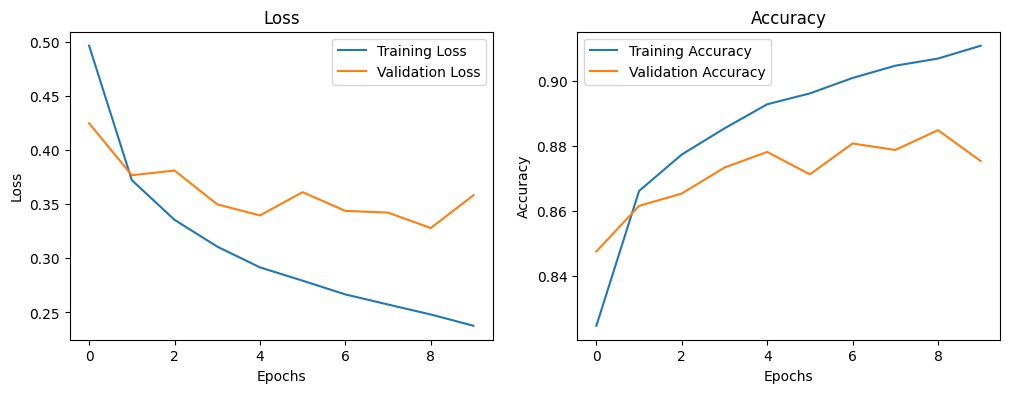

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Preprocess the data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Build the MLP model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),  # One hidden layer with 128 neurons
    Dense(10, activation='softmax')  # Output layer with 10 neurons (one for each class)
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test))

# Plot the loss and accuracy
plt.figure(figsize=(12, 4))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


### mlp with varying neuron count - Q2 part a

Training model with 100 neurons...
Training model with 200 neurons...
Training model with 300 neurons...
Training model with 400 neurons...


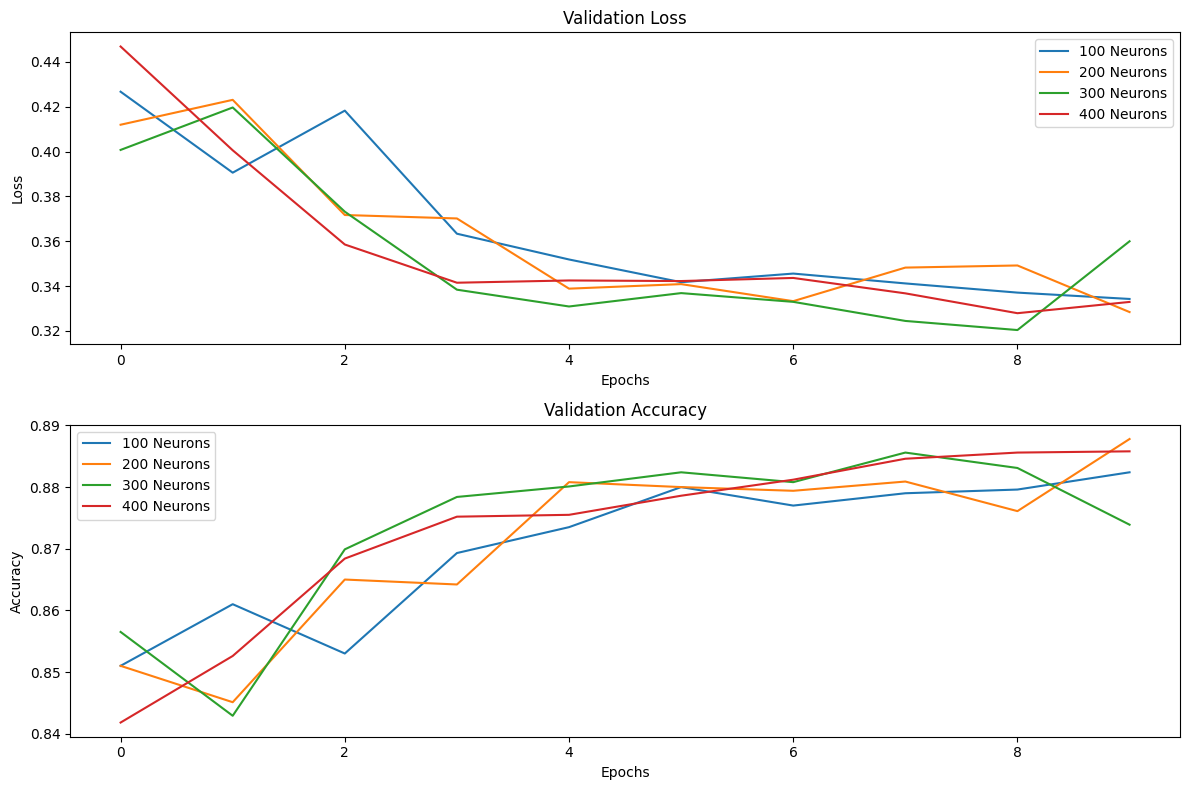

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Function to create, compile and train an MLP model
def create_and_train_model(neurons):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(neurons, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), verbose=0)

    return history

# Number of neurons to test
neurons_list = [100, 200, 300, 400]

# Dictionary to store the history of each model
histories = {}

# Train models with different number of neurons
for neurons in neurons_list:
    print(f'Training model with {neurons} neurons...')
    histories[neurons] = create_and_train_model(neurons)

# Plot the loss and accuracy for each model
plt.figure(figsize=(12, 8))

# Plot loss
plt.subplot(2, 1, 1)
for neurons in neurons_list:
    plt.plot(histories[neurons].history['val_loss'], label=f'{neurons} Neurons')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(2, 1, 2)
for neurons in neurons_list:
    plt.plot(histories[neurons].history['val_accuracy'], label=f'{neurons} Neurons')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### mlp with varying neuron count - Q2 part b


Training model with 256 and 128 neurons...
Training model with 128 and 256 neurons...
Training model with 256 and 256 neurons...
Training model with 128 and 128 neurons...
Training model with 300 and 300 neurons...
Training model with 400 and 300 neurons...
Training model with 400 and 400 neurons...


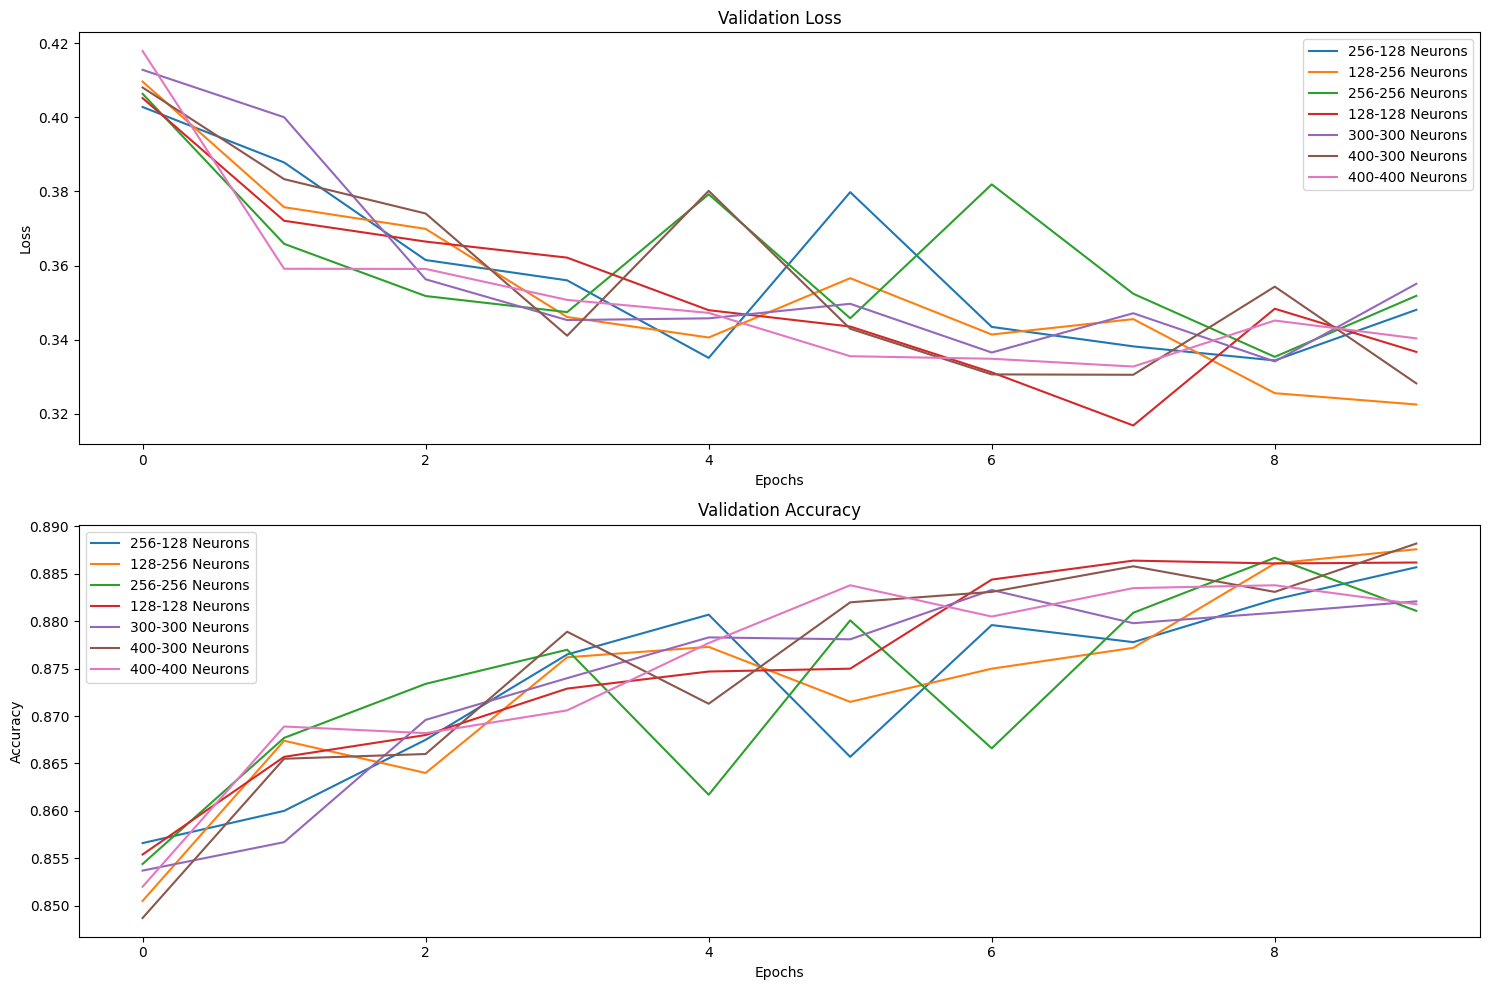

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Function to create, compile and train an MLP model with two hidden layers
def create_and_train_model(neurons1, neurons2):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(neurons1, activation='relu'),
        Dense(neurons2, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), verbose=0)

    return history

# Manually selected combinations of neurons for each hidden layer
selected_combinations = [
    (256, 128),
    (128, 256),
    (256, 256),
    (128, 128),
    (300, 300),
    (400, 300),
    (400, 400),
]

# Dictionary to store the history of each model
histories = {}

# Train models with selected combinations of neurons in two hidden layers
for neurons1, neurons2 in selected_combinations:
    print(f'Training model with {neurons1} and {neurons2} neurons...')
    histories[(neurons1, neurons2)] = create_and_train_model(neurons1, neurons2)

# Plot the loss and accuracy for each model
plt.figure(figsize=(15, 10))

# Plot loss
plt.subplot(2, 1, 1)
for (neurons1, neurons2) in histories:
    plt.plot(histories[(neurons1, neurons2)].history['val_loss'], label=f'{neurons1}-{neurons2} Neurons')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(2, 1, 2)
for (neurons1, neurons2) in histories:
    plt.plot(histories[(neurons1, neurons2)].history['val_accuracy'], label=f'{neurons1}-{neurons2} Neurons')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### dealing with overfit - Q3

Training model with 256 and 256 neurons...
Training model with 400 and 400 neurons...


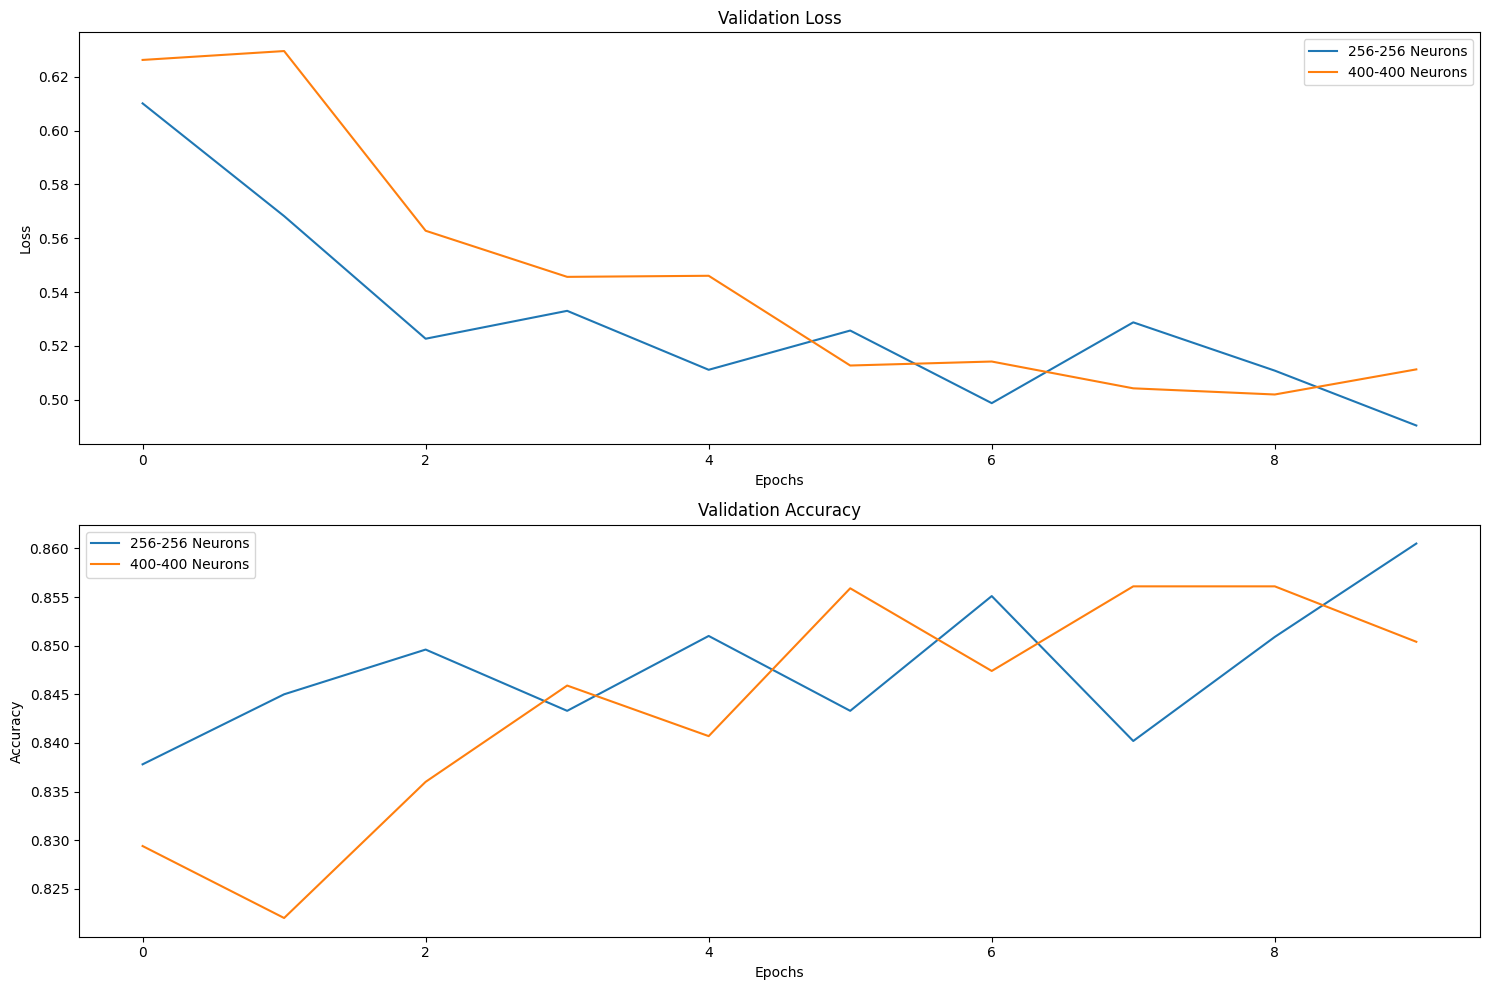

In [9]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


# Function to create, compile and train an MLP model with L2 regularization and Dropout
def create_and_train_model(neurons1, neurons2, reg, dropout_rate):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(neurons1, activation='relu', kernel_regularizer=l2(reg)),
        Dropout(dropout_rate),
        Dense(neurons2, activation='relu', kernel_regularizer=l2(reg)),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), verbose=0)

    return history

# Regularization parameter and dropout rate
regularization = 0.001
dropout_rate = 0.2

# Manually selected combinations of neurons for each hidden layer
selected_combinations = [
    (256, 256),
    (400, 400),
]

# Dictionary to store the history of each model
histories = {}

# Train models with selected combinations of neurons in two hidden layers
for neurons1, neurons2 in selected_combinations:
    print(f'Training model with {neurons1} and {neurons2} neurons...')
    histories[(neurons1, neurons2)] = create_and_train_model(neurons1, neurons2, regularization, dropout_rate)

# Plot the loss and accuracy for each model
plt.figure(figsize=(15, 10))

# Plot loss
plt.subplot(2, 1, 1)
for (neurons1, neurons2) in histories:
    plt.plot(histories[(neurons1, neurons2)].history['val_loss'], label=f'{neurons1}-{neurons2} Neurons')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(2, 1, 2)
for (neurons1, neurons2) in histories:
    plt.plot(histories[(neurons1, neurons2)].history['val_accuracy'], label=f'{neurons1}-{neurons2} Neurons')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### different optimizers - Q4

Training model with SGD optimizer...
Training model with RMSprop optimizer...
Training model with Adam optimizer...


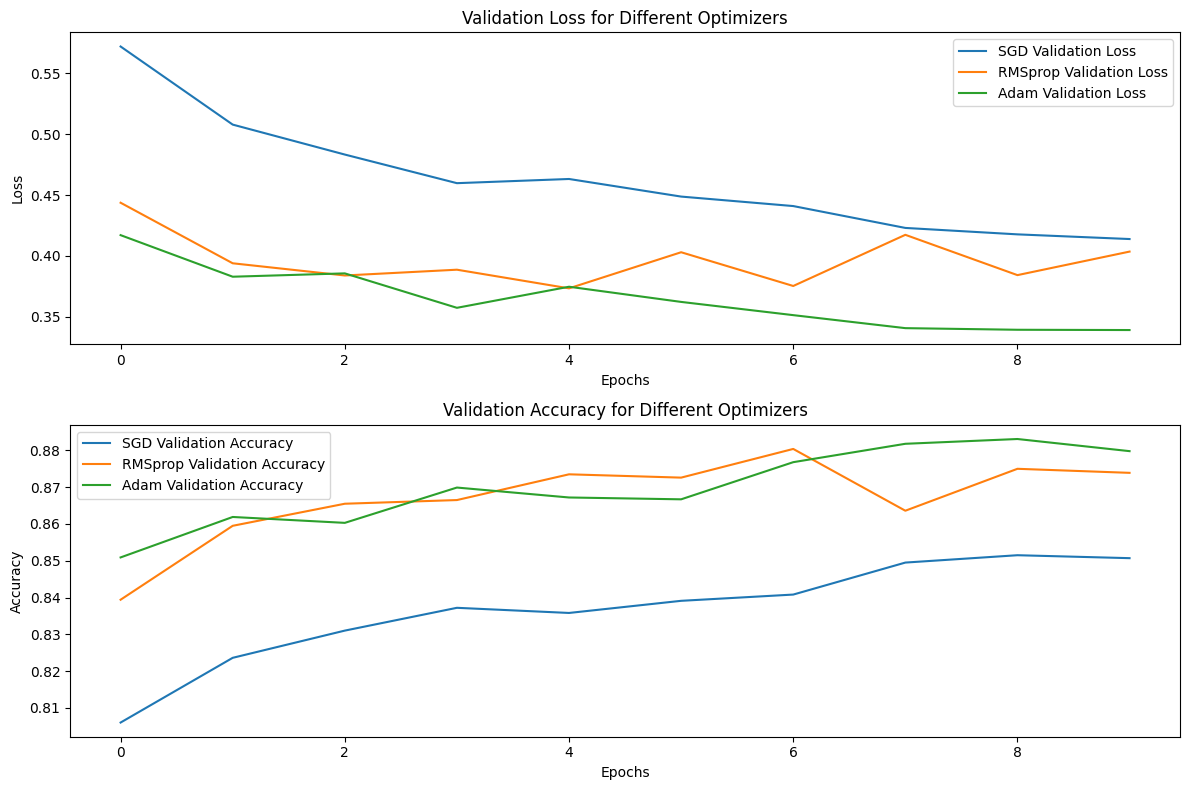

In [6]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Function to create, compile, and train the model with a specified optimizer
def create_and_train_model(optimizer_name):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'),  # One hidden layer with 128 neurons
        Dense(10, activation='softmax')  # Output layer with 10 neurons (one for each class)
    ])

    model.compile(optimizer=optimizer_name, loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), verbose=0)

    return history

# List of optimizers to test
optimizers = ['SGD', 'RMSprop', 'Adam']

# Dictionary to store the history of each model
histories = {}

# Train models with different optimizers
for optimizer in optimizers:
    print(f'Training model with {optimizer} optimizer...')
    histories[optimizer] = create_and_train_model(optimizer)

# Plot the loss and accuracy for each optimizer
plt.figure(figsize=(12, 8))

# Plot loss
plt.subplot(2, 1, 1)
for optimizer in optimizers:
    plt.plot(histories[optimizer].history['val_loss'], label=f'{optimizer} Validation Loss')
plt.title('Validation Loss for Different Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(2, 1, 2)
for optimizer in optimizers:
    plt.plot(histories[optimizer].history['val_accuracy'], label=f'{optimizer} Validation Accuracy')
plt.title('Validation Accuracy for Different Optimizers')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


### CNN - Q5

Training model with 2x2 kernel...
Training model with 4x4 kernel...
Training model with 6x6 kernel...


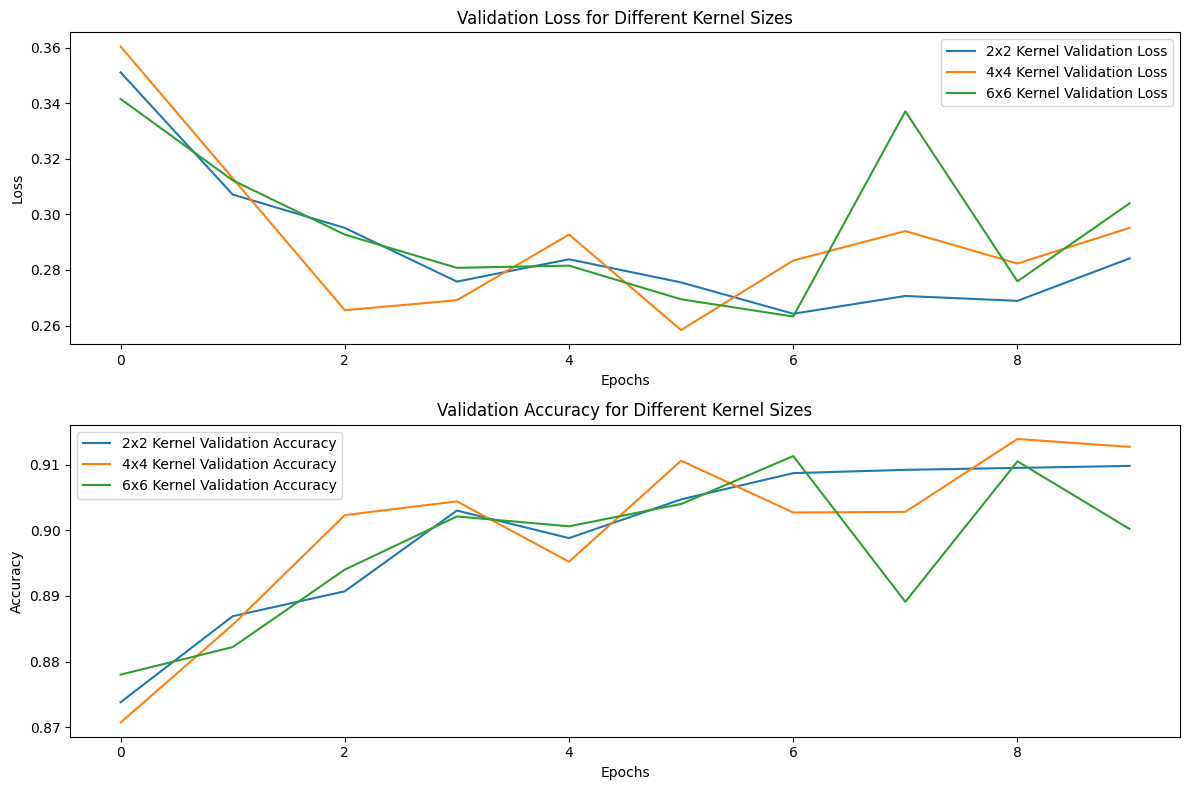

In [8]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Preprocess the data
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Function to create, compile, and train the CNN model with a specified kernel size
def create_and_train_model(kernel_size):
    model = Sequential([
        Conv2D(32, kernel_size=(kernel_size, kernel_size), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_test, y_test), verbose=0)

    return history

# List of kernel sizes to test
kernel_sizes = [2, 4, 6]

# Dictionary to store the history of each model
histories = {}

# Train models with different kernel sizes
for kernel_size in kernel_sizes:
    print(f'Training model with {kernel_size}x{kernel_size} kernel...')
    histories[kernel_size] = create_and_train_model(kernel_size)

# Plot the loss and accuracy for each kernel size
plt.figure(figsize=(12, 8))

# Plot loss
plt.subplot(2, 1, 1)
for kernel_size in kernel_sizes:
    plt.plot(histories[kernel_size].history['val_loss'], label=f'{kernel_size}x{kernel_size} Kernel Validation Loss')
plt.title('Validation Loss for Different Kernel Sizes')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(2, 1, 2)
for kernel_size in kernel_sizes:
    plt.plot(histories[kernel_size].history['val_accuracy'], label=f'{kernel_size}x{kernel_size} Kernel Validation Accuracy')
plt.title('Validation Accuracy for Different Kernel Sizes')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()
